<div style="background:#262766;color:white;padding:10px;text-align:center;font-size:26px">
Chargement et analyse des données sources
</div>

Les données sources proviennent du site data gouv
https://www.data.gouv.fr/datasets/donnees-climatologiques-de-base-quotidiennes/reuses_and_dataservices

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Dossier où sont stockés les 190 CSV
DATA_DIR = Path("data")
#Export du fichier fusionné
OUTPUT_FILE = "export/meteo_france_mensuel_1950_2026.csv"

In [3]:
#On concatène les fichiers puis on les sauvegarde dans un csv
files = sorted(DATA_DIR.glob("MENSQ_*_*.csv"))

first_file = True

for file in files:
    print("Traitement :", file.name)
    
    df = pd.read_csv(file, sep=";", low_memory=False)
    
    dep = file.name.split("_")[1]
    df["DEPARTEMENT"] = dep
    
    df.to_csv(
        OUTPUT_FILE,
        mode="w" if first_file else "a",
        index=False,
        header=first_file
    )
    
    first_file = False
    del df

print("Fusion terminée :", OUTPUT_FILE)


Traitement : MENSQ_01_latest-2025-2026.csv
Traitement : MENSQ_01_previous-1950-2024.csv
Traitement : MENSQ_02_latest-2025-2026.csv
Traitement : MENSQ_02_previous-1950-2024.csv
Traitement : MENSQ_03_latest-2025-2026.csv
Traitement : MENSQ_03_previous-1950-2024.csv
Traitement : MENSQ_04_latest-2025-2026.csv
Traitement : MENSQ_04_previous-1950-2024.csv
Traitement : MENSQ_05_latest-2025-2026.csv
Traitement : MENSQ_05_previous-1950-2024.csv
Traitement : MENSQ_06_latest-2025-2026.csv
Traitement : MENSQ_06_previous-1950-2024.csv
Traitement : MENSQ_07_latest-2025-2026.csv
Traitement : MENSQ_07_previous-1950-2024.csv
Traitement : MENSQ_08_latest-2025-2026.csv
Traitement : MENSQ_08_previous-1950-2024.csv
Traitement : MENSQ_09_latest-2025-2026.csv
Traitement : MENSQ_09_previous-1950-2024.csv
Traitement : MENSQ_10_latest-2025-2026.csv
Traitement : MENSQ_10_previous-1950-2024.csv
Traitement : MENSQ_11_latest-2025-2026.csv
Traitement : MENSQ_11_previous-1950-2024.csv
Traitement : MENSQ_12_latest-202

In [4]:
# Cahrgement du csv (par lot pour éviter la saturation de mémoire)
chunks = pd.read_csv(
    OUTPUT_FILE,
    sep=",",
    chunksize=100000,
    low_memory=True
)

total_rows = 0

for chunk in chunks:
    total_rows += len(chunk)

print(total_rows)

3263038


In [5]:
# Lire seulement l'en-tête
df_head = pd.read_csv(OUTPUT_FILE, sep=",", nrows=0)

nb_colonnes = len(df_head.columns)
colonnes = df_head.columns.tolist()

print("Nombre de lignes :", 3_262_696)
print("Nombre de colonnes :", nb_colonnes)


Nombre de lignes : 3262696
Nombre de colonnes : 163


In [6]:
#Couverture de période
chunks = pd.read_csv(
    OUTPUT_FILE,
    sep=",",
    usecols=["AAAAMM"],
    chunksize=100000
)

date_min = None
date_max = None

for chunk in chunks:
    current_min = chunk["AAAAMM"].min()
    current_max = chunk["AAAAMM"].max()

    date_min = current_min if date_min is None else min(date_min, current_min)
    date_max = current_max if date_max is None else max(date_max, current_max)

date_min_str = str(date_min)
date_max_str = str(date_max)

date_min_format = f"{date_min_str[4:6]}-{date_min_str[:4]}"
date_max_format = f"{date_max_str[4:6]}-{date_max_str[:4]}"

print(f"Période couverte : de {date_min_format} à {date_max_format}")

Période couverte : de 01-1950 à 06-2026


## Analyse de la complétude des colonnes

Ces analyses visent à voir dans les données à disposition celles explotables

In [7]:
# Calcul de la complétion des colonnes
chunks = pd.read_csv(OUTPUT_FILE, sep=",", chunksize=100000,low_memory=True)

total_rows = 0
non_null_counts = None

for chunk in chunks:
    total_rows += len(chunk)
    
    counts = chunk.notna().sum()
    
    if non_null_counts is None:
        non_null_counts = counts
    else:
        non_null_counts = non_null_counts.add(counts, fill_value=0)

completion_rate = (
    non_null_counts / total_rows * 100
).sort_values(ascending=False)

completion_df = completion_rate.reset_index()
completion_df.columns = ["colonne", "taux_completion_%"]

In [8]:
# Complétion des colonnes par mois
chunks = pd.read_csv(
    OUTPUT_FILE,
    sep=",",
    chunksize=100000,
    low_memory=True
)

total_par_mois = {}
non_null_par_mois = {}

for chunk in chunks:
    chunk["MOIS_ANNEE"] = chunk["AAAAMM"].astype(str).str.zfill(6)

    for mois, groupe in chunk.groupby("MOIS_ANNEE"):
        total_par_mois[mois] = total_par_mois.get(mois, 0) + len(groupe)

        counts = groupe.notna().sum()

        if mois not in non_null_par_mois:
            non_null_par_mois[mois] = counts
        else:
            non_null_par_mois[mois] = non_null_par_mois[mois].add(counts, fill_value=0)

completion_par_mois = pd.DataFrame(non_null_par_mois)

for mois in completion_par_mois.columns:
    completion_par_mois[mois] = completion_par_mois[mois] / total_par_mois[mois] * 100

completion_par_mois = completion_par_mois.round(2)

# Renommer les colonnes YYYYMM en MM-YYYY
completion_par_mois.columns = [
    f"{str(col)[4:6]}-{str(col)[:4]}"
    for col in completion_par_mois.columns
]

In [9]:
completion_par_mois.head()

,01-1950,02-1950,03-1950,04-1950,05-1950,06-1950,07-1950,08-1950,09-1950,10-1950,...,09-2025,10-2025,11-2025,12-2025,01-2026,02-2026,03-2026,04-2026,05-2026,06-2026
NUM_POSTE,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
NOM_USUEL,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
LAT,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
LON,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
ALTI,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


🔴 < 50 % → Exclure
<br/>Variable quasiment jamais renseignée.
<br/>Même si la complétion augmente, elle reste trop faible pour un modèle national.

🟡 50 % à 80 % → À évaluer
<br/>Variables potentiellement intéressantes mais spécialisées.
<br/>Elles pourront être utilisées selon le sujet ou la zone géographique.

🟢 ≥ 80 % → Variables de référence

In [10]:
# Variables toujours comprises entre 80 % et 100% de complétion
variables_fiables = completion_par_mois.index[
    completion_par_mois.min(axis=1) >= 80
]

print(f"{len(variables_fiables)} variables toujours au dessus de 80% :")
print(variables_fiables.tolist())

36 variables toujours au dessus de 80% :
['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMM', 'RR', 'QRR', 'NBRR', 'RRAB', 'QRRAB', 'NBJRR1', 'NBJRR5', 'NBJRR10', 'NBJRR30', 'NBJRR50', 'NBJRR100', 'NBPMERM', 'NBTX', 'NBTN', 'NBTAMPLI', 'NBTM', 'NBTMM', 'NBUN', 'NBUX', 'NBUM', 'NBFXI', 'NBFXY', 'NBFFM', 'NBINST', 'NBGLOT', 'NBDIFT', 'NBDIRT', 'NBHNEIGEF', 'DEPARTEMENT', 'MOIS_ANNEE']


In [11]:
# Variables toujours en dessous de 50 % de complétion
variables_a_exclure = completion_par_mois.index[
    completion_par_mois.max(axis=1) < 50
]

print(f"{len(variables_a_exclure)} variables toujours < 50 % :")
print(variables_a_exclure.tolist())

72 variables toujours < 50 % :
['RR_ME', 'PMERM', 'QPMERM', 'PMERMINAB', 'QPMERMINAB', 'PMERMINABDAT', 'TX_ME', 'TN_ME', 'UNAB', 'QUNAB', 'UNABDAT', 'UXAB', 'QUXAB', 'UXABDAT', 'UMM', 'QUMM', 'TSVM', 'QTSVM', 'FXIAB', 'QFXIAB', 'DXIAB', 'QDXIAB', 'FXIDAT', 'NBJFF10', 'NBJFF16', 'NBJFF28', 'FXI3SAB', 'QFXI3SAB', 'DXI3SAB', 'QDXI3SAB', 'FXI3SDAT', 'NBJFXI3S10', 'NBJFXI3S16', 'NBJFXI3S28', 'FXYAB', 'QFXYAB', 'DXYAB', 'QDXYAB', 'FXYABDAT', 'NBJFXY8', 'NBJFXY10', 'NBJFXY15', 'FFM', 'QFFM', 'INST', 'QINST', 'NBSIGMA0', 'NBSIGMA20', 'NBSIGMA80', 'GLOT', 'QGLOT', 'DIFT', 'QDIFT', 'DIRT', 'QDIRT', 'HNEIGEFTOT', 'QHNEIGEFTOT', 'HNEIGEFAB', 'QHNEIGEFAB', 'HNEIGEFDAT', 'NBJHNEIGEF1', 'NBJHNEIGEF5', 'NBJHNEIGEF10', 'NBJSOLNG', 'NEIGETOTM', 'QNEIGETOTM', 'NEIGETOTAB', 'QNEIGETOTAB', 'NEIGETOTABDAT', 'NBJNEIGETOT1', 'NBJNEIGETOT10', 'NBJNEIGETOT30']


In [12]:
variables_intermediaires = completion_par_mois.index.difference(
    list(variables_fiables) + list(variables_a_exclure)
)

print(len(variables_intermediaires))
print(variables_intermediaires.tolist())

56
['ETP', 'NBFXI3S', 'NBJBROU', 'NBJGELEE', 'NBJGREL', 'NBJNEIG', 'NBJORAG', 'NBJTMS24', 'NBJTN10', 'NBJTN5', 'NBJTNI10', 'NBJTNI15', 'NBJTNI20', 'NBJTNS20', 'NBJTNS25', 'NBJTX0', 'NBJTX25', 'NBJTX30', 'NBJTX35', 'NBJTXI20', 'NBJTXI27', 'NBJTXS32', 'NBTSVM', 'QETP', 'QTAMPLIAB', 'QTAMPLIM', 'QTM', 'QTMM', 'QTMMAX', 'QTMMIN', 'QTN', 'QTNAB', 'QTNMAX', 'QTX', 'QTXAB', 'QTXMIN', 'RRABDAT', 'TAMPLIAB', 'TAMPLIABDAT', 'TAMPLIM', 'TM', 'TMM', 'TMMAX', 'TMMAXDAT', 'TMMIN', 'TMMINDAT', 'TN', 'TNAB', 'TNDAT', 'TNMAX', 'TNMAXDAT', 'TX', 'TXAB', 'TXDAT', 'TXMIN', 'TXMINDAT']


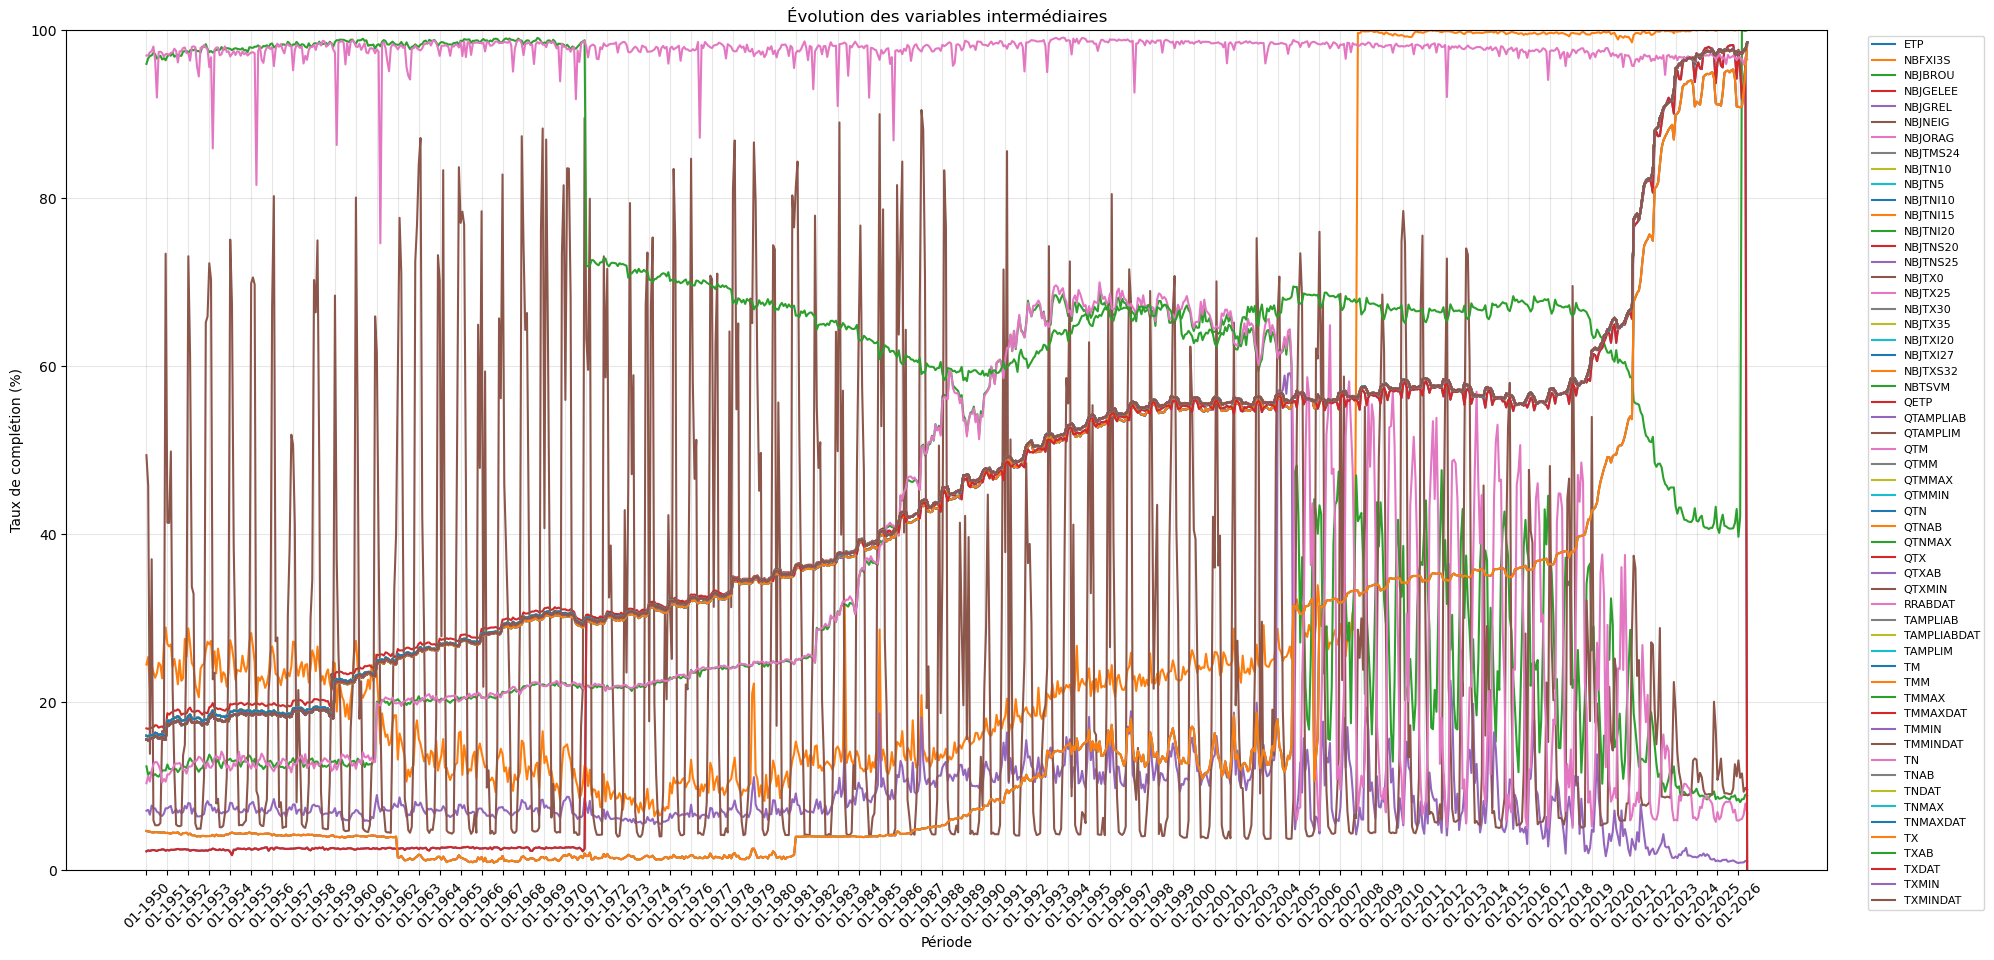

In [13]:
plt.figure(figsize=(20, 10))

for var in variables_intermediaires:
    plt.plot(
        completion_par_mois.columns,
        completion_par_mois.loc[var],
        label=var,
        linewidth=1.5
    )

plt.title("Évolution des variables intermédiaires")
plt.xlabel("Période")
plt.ylabel("Taux de complétion (%)")
plt.ylim(0, 100)

xticks = [
    i for i, c in enumerate(completion_par_mois.columns)
    if c.startswith("01-")
]

plt.xticks(
    xticks,
    [completion_par_mois.columns[i] for i in xticks],
    rotation=45
)

plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

In [14]:
stats = pd.DataFrame({
    "min": completion_par_mois.min(axis=1),
    "moyenne": completion_par_mois.mean(axis=1),
    "max": completion_par_mois.max(axis=1)
})

stats.loc[variables_intermediaires].sort_values(
    "min",
    ascending=False
).head(164)

,min,moyenne,max
RRABDAT,74.60,97.686068,99.10
NBTSVM,39.65,73.381078,100.00
NBJGELEE,16.78,45.031024,98.53
TNDAT,15.90,44.791993,98.53
NBJTNI20,15.90,44.530229,98.48
QTNAB,15.90,44.791993,98.53
QTN,15.90,44.777146,98.48
TN,15.90,44.776710,98.48
TNAB,15.90,44.791993,98.53
TNMAX,15.90,44.790261,98.53


In [16]:
variables_temp = ["TX", "TN", "TM"]

# On transpose pour avoir les périodes en lignes
completion_temp = completion_par_mois.loc[variables_temp].T.copy()

# Conversion de l'index en texte
completion_temp.index = completion_temp.index.astype(str)

# Extraction de l'année
# Cas format "01-1990"
completion_temp["ANNEE"] = completion_temp.index.str[-4:].astype(int)

# Complétude annuelle moyenne
completion_temp_annee = (
    completion_temp
    .groupby("ANNEE")[variables_temp]
    .mean()
    .round(2)
)

pd.set_option("display.max_rows", None)
completion_temp_annee = completion_temp_annee.loc[1990:2026]

completion_temp_annee

,TX,TN,TM
ANNEE,,,
1990,47.69,47.70,47.67
1991,48.94,48.91,48.88
1992,50.72,50.74,50.70
1993,51.83,51.86,51.79
1994,52.79,52.81,52.76
1995,53.91,53.90,53.85
1996,54.57,54.58,54.50
1997,55.31,55.31,55.25
1998,55.65,55.66,55.62


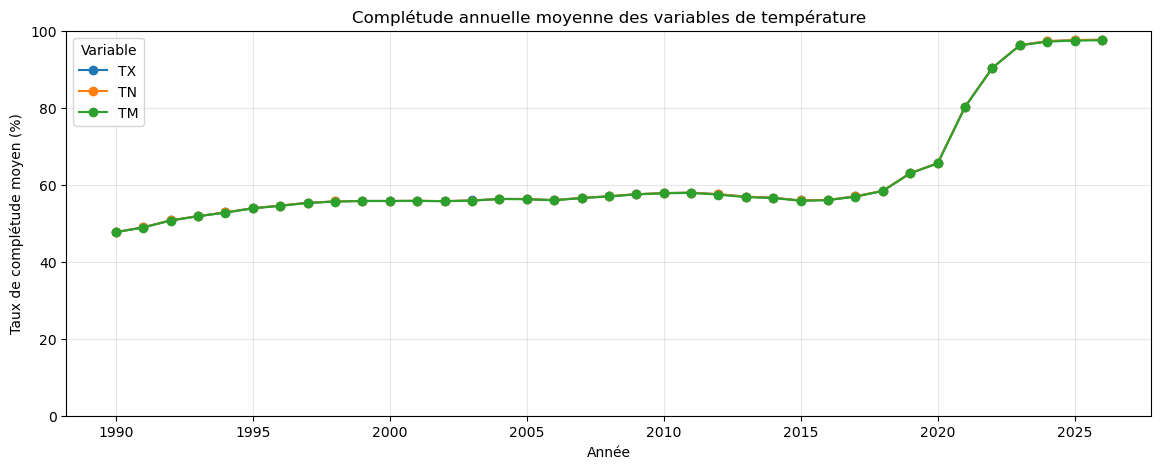

In [17]:
plt.figure(figsize=(14, 5))

for var in variables_temp:
    plt.plot(
        completion_temp_annee.index,
        completion_temp_annee[var],
        marker="o",
        label=var
    )

plt.title("Complétude annuelle moyenne des variables de température")
plt.xlabel("Année")
plt.ylabel("Taux de complétude moyen (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend(title="Variable")

plt.show()

## Sélection des variables

L'objectif est de construire un jeu de données robuste pour prédire les températures minimale, maximale et moyenne.

L'analyse de complétude sur la période complète montre que les variables de température `TX`, `TN` et `TM` sont peu complètes avant 2021, mais atteignent un niveau de complétude satisfaisant à partir de 2021.

Le choix retenu est donc de réduire la période d'étude à **2021–2026** afin de conserver les variables essentielles au modèle tout en limitant fortement les valeurs manquantes.

### Critère de sélection retenu

Les variables sont conservées si leur taux de complétion est supérieur ou égal à **80 % sur chaque mois à partir de janvier 2021**.

Cette stratégie permet :
- de conserver les variables cibles `TX`, `TN` et `TM` ;
- de travailler sur une période récente et mieux renseignée ;
- de limiter les traitements d'imputation ;
- de construire un jeu de données plus fiable pour la modélisation.

Le jeu de données final est donc construit à partir des observations disponibles entre **janvier 2021 et juin 2026**.

In [25]:
print(completion_par_mois.columns[:10])
print(type(completion_par_mois.columns[0]))

Index(['01-1950', '02-1950', '03-1950', '04-1950', '05-1950', '06-1950',
       '07-1950', '08-1950', '09-1950', '10-1950'],
      dtype='object')
<class 'str'>


In [ ]:
# Conversion des colonnes en dates
completion_tmp = completion_par_mois.copy()
completion_tmp.columns = pd.to_datetime(
    completion_tmp.columns.astype(str),
    errors="coerce"
)

# Filtre 2021 à 2025
completion_2021_2025 = completion_tmp.loc[
    :,
    (completion_tmp.columns >= "2021-01-01") &
    (completion_tmp.columns <= "2025-12-01")
]

print(completion_2021_2025.shape)

stats_2021_2025 = pd.DataFrame({
    "min": completion_2021_2025.min(axis=1),
    "moyenne": completion_2021_2025.mean(axis=1),
    "max": completion_2021_2025.max(axis=1)
})

variables_finales = (
    stats_2021_2025
    .loc[stats_2021_2025["moyenne"] >= 80]
    .index
    .tolist()
)

print(f"{len(variables_finales)} variables conservées")
print(variables_finales)


(164, 60)
87 variables conservées
['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMM', 'RR', 'QRR', 'NBRR', 'RRAB', 'QRRAB', 'RRABDAT', 'NBJRR1', 'NBJRR5', 'NBJRR10', 'NBJRR30', 'NBJRR50', 'NBJRR100', 'NBPMERM', 'TX', 'QTX', 'NBTX', 'TXAB', 'QTXAB', 'TXDAT', 'TXMIN', 'QTXMIN', 'TXMINDAT', 'NBJTX0', 'NBJTX25', 'NBJTX30', 'NBJTX35', 'NBJTXI20', 'NBJTXI27', 'NBJTXS32', 'TN', 'QTN', 'NBTN', 'TNAB', 'QTNAB', 'TNDAT', 'TNMAX', 'QTNMAX', 'TNMAXDAT', 'NBJTN5', 'NBJTN10', 'NBJTNI10', 'NBJTNI15', 'NBJTNI20', 'NBJTNS20', 'NBJTNS25', 'NBJGELEE', 'TAMPLIM', 'QTAMPLIM', 'TAMPLIAB', 'QTAMPLIAB', 'TAMPLIABDAT', 'NBTAMPLI', 'TM', 'QTM', 'NBTM', 'TMM', 'QTMM', 'NBTMM', 'NBJTMS24', 'TMMIN', 'QTMMIN', 'TMMINDAT', 'TMMAX', 'QTMMAX', 'TMMAXDAT', 'NBUN', 'NBUX', 'NBUM', 'ETP', 'QETP', 'NBFXI', 'NBFXI3S', 'NBFXY', 'NBFFM', 'NBINST', 'NBGLOT', 'NBDIFT', 'NBDIRT', 'NBHNEIGEF', 'DEPARTEMENT', 'MOIS_ANNEE']


C:\Users\Lily\AppData\Local\Temp\ipykernel_15160\3578463738.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  completion_tmp.columns = pd.to_datetime(


,min,moyenne,max
TX,77.43,92.353000,97.74
TN,77.51,92.360667,97.74
TM,77.26,92.265833,97.68


In [28]:
# ==========================================================
# Paramètres
# ==========================================================

DATE_DEBUT = 202101
DATE_FIN = 202606
FICHIER_SORTIE = "export/donnees_meteo_finales_2021_2026.csv"

# ==========================================================
# Vérification des variables
# ==========================================================

colonnes_csv = pd.read_csv(
    OUTPUT_FILE,
    sep=",",
    nrows=0
).columns.tolist()

variables_finales_ok = [
    var for var in variables_finales
    if var in colonnes_csv
]

variables_manquantes = [
    var for var in variables_finales
    if var not in colonnes_csv
]

print("Variables manquantes :", variables_manquantes)
print(f"Variables conservées : {len(variables_finales_ok)}")

# ==========================================================
# Chargement du jeu de données 2021-2026
# ==========================================================

chunks = []

for chunk in pd.read_csv(
    OUTPUT_FILE,
    sep=",",
    usecols=variables_finales_ok,
    chunksize=100000,
    low_memory=True
):
    chunk = chunk[
        (chunk["AAAAMM"] >= DATE_DEBUT) &
        (chunk["AAAAMM"] <= DATE_FIN)
    ]

    chunks.append(chunk)

df_final = pd.concat(chunks, ignore_index=True)

# ==========================================================
# Création de la colonne date
# ==========================================================

df_final["MOIS_ANNEE"] = pd.to_datetime(
    df_final["AAAAMM"].astype(str),
    format="%Y%m"
)

# ==========================================================
# Informations
# ==========================================================

print("\n==============================")
print("Jeu de données final")
print("==============================")
print(f"Période : {df_final['AAAAMM'].min()} -> {df_final['AAAAMM'].max()}")
print(f"Nombre de lignes : {df_final.shape[0]:,}".replace(",", " "))
print(f"Nombre de colonnes : {df_final.shape[1]}")
print(f"Nombre de bornes : {df_final['NUM_POSTE'].nunique()}")
print(f"Nombre de départements : {df_final['DEPARTEMENT'].nunique()}")

# ==========================================================
# Export
# ==========================================================

df_final.to_csv(
    FICHIER_SORTIE,
    index=False
)

print(f"\nFichier exporté : {FICHIER_SORTIE}")

df_final.head()

Variables manquantes : ['MOIS_ANNEE']
Variables conservées : 86

Jeu de données final
Période : 202101 -> 202606
Nombre de lignes : 133 878
Nombre de colonnes : 87
Nombre de bornes : 2502
Nombre de départements : 95

Fichier exporté : export/donnees_meteo_finales_2021_2026.csv


,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMM,RR,QRR,NBRR,RRAB,...,NBFXI3S,NBFXY,NBFFM,NBINST,NBGLOT,NBDIFT,NBDIRT,NBHNEIGEF,DEPARTEMENT,MOIS_ANNEE
0,1014002,ARBENT,46.278167,5.669,534,202501,187.3,1.0,31.0,46.0,...,31.0,31.0,31.0,0.0,0.0,0.0,0.0,0.0,1,2025-01-01
1,1014002,ARBENT,46.278167,5.669,534,202502,54.0,1.0,28.0,23.0,...,28.0,28.0,28.0,0.0,0.0,0.0,0.0,0.0,1,2025-02-01
2,1014002,ARBENT,46.278167,5.669,534,202503,64.2,1.0,31.0,15.6,...,31.0,31.0,31.0,0.0,0.0,0.0,0.0,0.0,1,2025-03-01
3,1014002,ARBENT,46.278167,5.669,534,202504,126.0,1.0,30.0,37.4,...,30.0,30.0,30.0,0.0,0.0,0.0,0.0,0.0,1,2025-04-01
4,1014002,ARBENT,46.278167,5.669,534,202505,133.7,1.0,31.0,46.8,...,31.0,31.0,31.0,0.0,0.0,0.0,0.0,0.0,1,2025-05-01
